# **Assignment 1** #
### **Probability, Linear Algebra, and Computational Programming** ###

## Aesha Gandhi ##
## 2026-01-11 ##

<div style="page-break-before: always;"></div>


In [ ]:
%%capture
# install
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install openpyxl
!pip install scipy
!pip install nbconvert
!pip install pandoc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import nbconvert
import os




<div style="page-break-before: always;"></div>


## **Exercise 1:  Probabilistic Reasoning** ##

### 1.1 ### 
P( X = 10| Roll 1 = 1) = P(Roll 2 + 3 = 9) 

Roll 2 and 3 sum to 9 if the outcomes of roll 1 and 2 are (3,6), (4,5), (5,4), (6,3) out of 36 possible outcomes

Thus 4 out of 36 possible outcomes --> 1/9


### 1.2 ###

In [40]:
import random
dice = [1,2,3,4,5,6]
roll = random.choice(dice)

counter = 0
roll_one_is_one = 0 
for i in range(1000000):
    roll_1 = random.choice(dice)
    roll_2 = random.choice(dice)
    roll_3 = random.choice(dice)
    if roll_1 == 1:
        roll_one_is_one += 1
        total = roll_1 + roll_2 + roll_3
        if total == 10:
            counter += 1

print("The probability of rolling a total of 10 with the first die being 1 is approximately:", counter / roll_one_is_one)
            
    
    



The probability of rolling a total of 10 with the first die being 1 is approximately: 0.11028485001260398


### 1.3 ###

P(positive | has disease) = 0.95

P(positive | no disease) = 0.03

P(has disease) = 1/1000

P(has disease | positive) = (P(positive | has disease) * P(has disease)) / (P(positive))

P(positive) = P(has disease) P(positive | has disease) + P(no disease) P(positive | no disease)
            
            
            
Then, P(has disease | positive)  = (0.001 * 0.95) / (0.001 * 0.95 + (1-0.001) * (0.03))
           
            
P(has disease | positive) = 0.0307



    

In [3]:
q1_3 = (0.001 * 0.95) / (0.001*0.95 + (1-0.001)*(0.03))
print("The probability that a person has the disease given that they tested positive is approximately:", q1_3)

The probability that a person has the disease given that they tested positive is approximately: 0.03072445019404916


### 1.4 ###

E[X] = -1 * P(X = -1) + 0 * O(X = 0) + 1 * P(X = 0.3)

     = -1 * 0.2 + 1 * 0.3

     = 0.1

Var[X] = E[$X^2$] - $E[X]^2$

E[$X^2$] = $(-1)^2$ * P(X = -1) + 0 * O(X = 0) + $1^2$ * P(X = 0.3)

         = 1 * P(X = -1) + 1 * P(X = 0.3) 
         
         = 1 * 0.2 + 1 * 0.3

         = 0.5


Then, Var[X] = E[$X^2$] - $E[X]^2$ 
             
             = $(0.5)^2$ - $(0.1)^2$ 
             
             =  0.24

See code below for full output:



In [4]:
theoretical_mean = (-1 * 0.2) + (1 * 0.3)
# rounding to avoid floating point precision issues

theoretical_var = ((1 * 0.2 + 1 * 0.3) ** 2) - (theoretical_mean**2)
theoretical_std = theoretical_var ** 0.5

print("Expected value E[X]:", round(theoretical_mean, 2))
print("Variance Var(X):", round(theoretical_var, 2))
print("Standard deviation:", round(theoretical_std, 2))

Expected value E[X]: 0.1
Variance Var(X): 0.24
Standard deviation: 0.49


<div style="page-break-before: always;"></div>


## **Exercise 2: Probability Distributions and Modeling** ##

### 2.1 ###

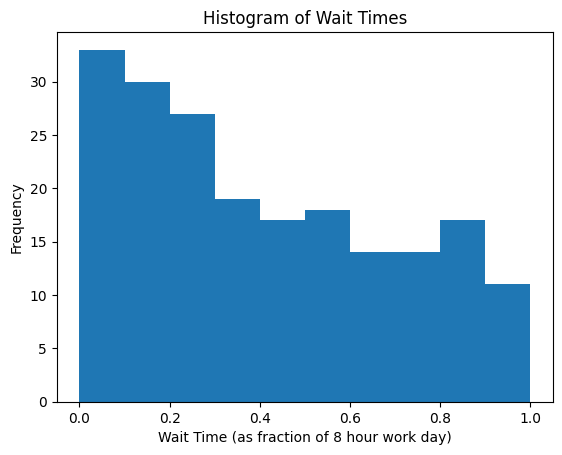

In [5]:
# load in wait_times.csv using np.loadtxt()
wait_times = np.loadtxt('wait_times.csv', delimiter=',')

# plot histogram of wait_times

import matplotlib.pyplot as plt
plt.hist(wait_times, bins=10, range=(0, 1))
plt.xlabel('Wait Time (as fraction of 8 hour work day)')
plt.ylabel('Frequency')
plt.title('Histogram of Wait Times')
plt.show()

### 2.2 ####

In [6]:
# mean, variance, std of wait times
# convert mean and std to hours
mean_wait = np.mean(wait_times)
mean_wait_hours = mean_wait * 8  # convert to hours
var_wait = np.var(wait_times)
std_wait = np.std(wait_times)
std_wait_hours = std_wait * 8  # convert to hours

# print and describe in both original units and converted units
print(f"Mean wait time: {mean_wait:.4f} (fraction of work day), {mean_wait_hours:.2f} hours")
print(f"Variance of wait times: {var_wait:.6f} (fraction of work day squared)")
print(f"Standard deviation of wait times: {std_wait:.4f} (fraction of work day), {std_wait_hours:.2f} hours")



Mean wait time: 0.4042 (fraction of work day), 3.23 hours
Variance of wait times: 0.081548 (fraction of work day squared)
Standard deviation of wait times: 0.2856 (fraction of work day), 2.28 hours


### 2.3 ###

To form a valid probability distribution, it must sum to 1 over all possible values.
$$
\int_{0}^{1} \alpha e^{-x} \, dx = 1
$$

$$
\alpha \int_{0}^{1} e^{-x} \, dx = 1
$$

$$
\alpha \left[ -e^{-x} \right]_{0}^{1} = 1
$$

$$
\alpha \left( -e^{-1} + e^{0} \right) = 1
$$

$$
\alpha \left( 1 - \frac{1}{e} \right) = 1
$$

$$
\alpha = \frac{1}{\left(1 - \frac{1}{e}\right)} = \frac{e}{e - 1}
$$




**The value of alpha that makes the pdf a valid probability density function is $\frac{e}{e - 1}$ ~ 1.582.**

In [7]:
alpha = np.e / (np.e - 1)
alpha

1.5819767068693265

### 2.4 ####

![Alt text](q2_4.jpeg)


### 2.5 ####

![Alt text](q2_5.jpeg)




### 2.6 ####
![Alt text](q2_6.jpeg)



### 2.7 ####

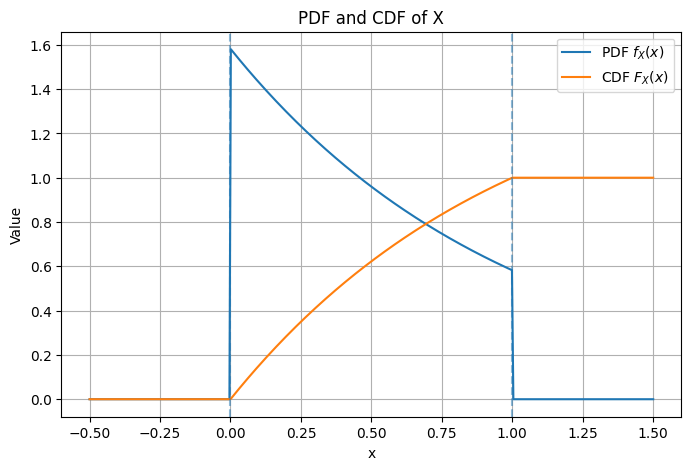

In [33]:
import numpy as np
import matplotlib.pyplot as plt

alpha = np.e / (np.e - 1)

def pdf(x):
    x = np.asarray(x)
    return np.where((x >= 0) & (x <= 1), alpha * np.exp(-x), 0.0)

def cdf(x):
    x = np.asarray(x)
    return np.where(
        x < 0, 0.0,
        np.where(x <= 1, alpha * (1 - np.exp(-x)), 1.0)
    )

x_vals = np.linspace(-0.5, 1.5, 400)
pdf_vals = pdf(x_vals)
cdf_vals = cdf(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, pdf_vals, label="PDF $f_X(x)$")
plt.plot(x_vals, cdf_vals, label="CDF $F_X(x)$")
plt.axvline(0, linestyle="--", alpha=0.5)
plt.axvline(1, linestyle="--", alpha=0.5)
plt.xlabel("x")
plt.ylabel("Value")
plt.title("PDF and CDF of X")
plt.legend()
plt.grid(True)
plt.show()


2.8

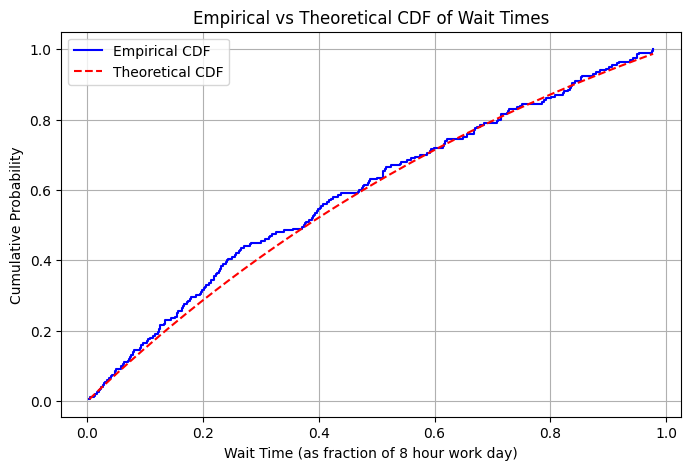

In [34]:
# empirical cdf from wait times data by sorting data in ascending oder of x values, and assigning y as cumulative probabilities
sorted_wait_times = np.sort(wait_times)
n = len(sorted_wait_times)
empirical_cdf = np.arange(1, n+1) / n

# plot emprical cdf and compareto the theoretical cdf
theoretical_cdf_vals = cdf(sorted_wait_times)
plt.figure(figsize=(8,5))
plt.step(sorted_wait_times, empirical_cdf, where='post', label='Empirical CDF', color='blue')
plt.plot(sorted_wait_times, theoretical_cdf_vals, label='Theoretical CDF', color='red', linestyle='--')
plt.xlabel('Wait Time (as fraction of 8 hour work day)')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical CDF of Wait Times')
plt.legend()
plt.grid(True)
plt.show()

2.9

In [ ]:
# inverse cdf 

# already have cdf defined above
def inverse_cdf(u):
    if 0 <= u < alpha * (1 - np.exp(-1)):
        return -np.log(1 - u / alpha)
    elif u >= alpha * (1 - np.exp(-1)) and u <= 1:
        return 1
    else:
        raise ValueError("u must be in [0, 1]")
v_inverse_cdf = np.vectorize(inverse_cdf)
# generate uniform samples and transform using inverse cdf
uniform_samples = np.random.rand(10000)
X = v_inverse_cdf(uniform_samples)
X


array([0.20169949, 0.64246068, 0.14571208, ..., 0.01145313, 0.12592069,
       0.05309091], shape=(10000,))

### 2.10 ###

In [44]:


synthetic_mean = np.mean(X)
synthetic_std = np.std(X, ddof=1)

theoretical_mean = alpha * (1- 2/np.e)
theoretical_std = np.sqrt((alpha * (2 - 5/np.e)) - (theoretical_mean ** 2))

# Empirical stats from wait_times.csv
empirical_mean = np.mean(wait_times)
empirical_std = np.std(wait_times, ddof=1)


results = pd.DataFrame({
    "Type": ["Empirical (wait_times.csv)", "Theoretical", "Synthetic (Inverse CDF)"],
    "Mean": [empirical_mean, theoretical_mean, synthetic_mean],
    "Std Dev": [empirical_std, theoretical_std, synthetic_std]
})

results



,Type,Mean,Std Dev
0,Empirical (wait_times.csv),0.404196,0.286283
1,Theoretical,0.418023,0.281649
2,Synthetic (Inverse CDF),0.417245,0.280452


**The synthetic data generated using the inverse CDF closely matches the empirical data in both mean and standard deviation, showing that the inverse CDF method may mimic the main behavior of the observed wait times. The empricial data is similar to the theoretical model but doesn't match as closely as the synthetic method did, with slightly bigger differences in the mean and standard deviation. This suggests that there could be differences in the actual waiting times that isn't modeled exactly by our exponential theoretical model, and there could be more complexities in the features.**

### 2.11 ###

In [ ]:
from scipy.stats import ks_2samp

#  KS Test 1: Empirical vs Synthetic Model 
ks_stat_model, pval_model = ks_2samp(wait_times, X)

print("KS Test: Empirical vs Synthetic Model")
print("KS statistic:", ks_stat_model)
print("p-value:", pval_model)

if pval_model > 0.05:
    print("Fail to reject H0: Data are consistent with the model distribution.")
else:
    print("Reject H0: Data do NOT match the model distribution.")

print()

#  KS Test 2: Empirical vs Uniform 
ks_stat_uniform, pval_uniform = ks_2samp(wait_times, uniform_samples)

print("KS Test: Empirical vs Uniform")
print("KS statistic:", ks_stat_uniform)
print("p-value:", pval_uniform)

if pval_uniform > 0.05:
    print("Fail to reject H0: Data look uniform (unexpected).")
else:
    print("Reject H0: Data are NOT uniform.")


KS Test: Empirical vs Synthetic Model
KS statistic: 0.0701
p-value: 0.27766111477408545
Fail to reject H0: Data are consistent with the model distribution.

KS Test: Empirical vs Uniform
KS statistic: 0.1692
p-value: 2.2520209021375923e-05
Reject H0: Data are NOT uniform.


**At the 5% significance level, the KS test comparing the empirical wait times to the synthetic model sample gives a p-value of 0.278, so we fail to reject the null hypothesis and cannot conclude that the model distribution is different from the data, while the KS test against a uniform distribution gives a very small p-value, so we reject the null hypothesis and conclude that the wait time data are not uniformly distributed.**

### 2.12 ###

In [14]:
# X is the synthetic samples I already generated from the inverse CDF
# 1) P(wait > 6 hours)  -> 6/8 of day
p_gt_6 = np.mean(X > 6/8)

# 2) P(wait < 1 hour) -> 1/8 of day
p_lt_1 = np.mean(X < 1/8)

# 3) P(wait < 4 | already waited 3)
p_between_3_4 = np.mean((X > 3/8) & (X < 4/8))
p_gt_3 = np.mean(X > 3/8)
p_cond = p_between_3_4 / p_gt_3

# 4) P(3 < wait < 5 hours)
p_between_3_5 = np.mean((X > 3/8) & (X < 5/8))

# 5) 90th percentile
p90 = np.percentile(X, 90)

# 6) 99th percentile
p99 = np.percentile(X, 99)

print("P(wait > 6 hours):", p_gt_6)
print("P(wait < 1 hour):", p_lt_1)
print("P(wait < 4 | waited 3):", p_cond)
print("P(3 < wait < 5 hours):", p_between_3_5)
print("90th percentile (hours):", p90 * 8)
print("99th percentile (hours):", p99 * 8)



P(wait > 6 hours): 0.1628
P(wait < 1 hour): 0.1856
P(wait < 4 | waited 3): 0.2566771406127259
P(3 < wait < 5 hours): 0.2486
90th percentile (hours): 6.708448023984146
99th percentile (hours): 7.86545041044052


<div style="page-break-before: always;"></div>


## **Exercise 3: Linear Algebra Operations and Theory** ##

### 3.1 ###
![Alt text](q3_1.jpeg)


### 3.2 ###

In [35]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

b = np.array([[-1],
              [ 1]])

c = np.array([[1],
              [2]])

print("A =\n", A)
print("b =\n", b)
print("c =\n", c)

# 1. A @ A
print("\n1. A @ A =\n", A @ A)

# 2. A @ A.T
print("\n2. A @ A.T =\n", A @ A.T)

# 3. A @ b
print("\n3. A @ b =\n", A @ b)

# 4. A @ b.T  (invalid: (2x2) @ (1x2))
# print(A @ b.T)

# 5. b @ A (invalid: (2x1) @ (2x2))
# print(b @ A)

# 6. b.T @ A
print("\n6. b.T @ A =\n", b.T @ A)

# 7. b @ b (invalid: (2x1) @ (2x1))
# print(b @ b)

# 8. b.T @ b
print("\n8. b.T @ b =\n", b.T @ b)

# 9. b @ b.T
print("\n9. b @ b.T =\n", b @ b.T)

# 10. A * A (element-wise)
print("\n10. A * A =\n", A * A)

# 11. b * c (element-wise)
print("\n11. b * c =\n", b * c)

# 12. b.T @ b.T (invalid: (1x2) @ (1x2))
# print(b.T @ b.T)

# 13. b + c.T (invalid mathematically, but NumPy broadcasts)
print("\n13. b + c.T (broadcasted, not valid linear algebra):\n", b + c.T)

# 14. A^{-1} @ b
A_inv = np.linalg.inv(A)
print("\n14. A^{-1} @ b =\n", A_inv @ b)

# 15. b.T @ A @ b
print("\n15. b.T @ A @ b =\n", b.T @ A @ b)

# 16. b @ A @ b.T (invalid because b @ A is invalid)
# print(b @ A @ b.T)


A =
 [[1 2]
 [3 4]]
b =
 [[-1]
 [ 1]]
c =
 [[1]
 [2]]

1. A @ A =
 [[ 7 10]
 [15 22]]

2. A @ A.T =
 [[ 5 11]
 [11 25]]

3. A @ b =
 [[1]
 [1]]

6. b.T @ A =
 [[2 2]]

8. b.T @ b =
 [[2]]

9. b @ b.T =
 [[ 1 -1]
 [-1  1]]

10. A * A =
 [[ 1  4]
 [ 9 16]]

11. b * c =
 [[-1]
 [ 2]]

13. b + c.T (broadcasted, not valid linear algebra):
 [[0 1]
 [2 3]]

14. A^{-1} @ b =
 [[ 3.]
 [-2.]]

15. b.T @ A @ b =
 [[0]]


### Explanation of Invalid Cases

Some operations cannot be computed because matrix multiplication requires the inner dimensions to match. For example, `A @ b.T` (#4) is invalid because a 2×2 matrix cannot multiply a 1×2 matrix, and `b @ A` (#5) is invalid because a 2×1 matrix cannot multiply a 2×2 matrix. Similar dimension mismatches make expressions like `b @ b` (#7) and `b.T @ b.T` (#12) invalid as well.

One special case is `b + c.T` (#13). In linear algebra, addition requires matrices to have the same shape, and here `b` is 2×1 while `c.T` is 1×2, so the operation is mathematically invalid. However, NumPy applies broadcasting rules and produces a result anyway, which is why no error is raised even though the operation is not a valid linear algebra computation.


### 3.3 ###
![Alt text](q3_3.jpeg)


### 3.4 ###
![Alt text](q3_4.jpeg)


### 3.5 ##

In [16]:
B = np.array([[1, 2, 3],
              [2, 4, 5],
              [3, 5, 6]])

# calculate the eigenvalues and corresponding eigenvectors of matrix 
eigenvalues, eigenvectors = np.linalg.eig(B)
# output results 
print("Eigenvalues of B:\n", eigenvalues)
print("\nEigenvectors of B:\n", eigenvectors)


Eigenvalues of B:
 [11.34481428 -0.51572947  0.17091519]

Eigenvectors of B:
 [[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]


In [17]:
# Choose one of the eigenvector/eigenvalue pairs, and and show that lambda *v = B @ v
lambda_1 = eigenvalues[0]
v_1 = eigenvectors[:, 0]
print(f"\nVerifying for eigenvalue λ = {lambda_1} and corresponding eigenvector v = {v_1}:\n")
print("λ * v =\n", lambda_1 * v_1)
print("B @ v =\n", B @ v_1)
 



Verifying for eigenvalue λ = 11.344814282762082 and corresponding eigenvector v = [-0.32798528 -0.59100905 -0.73697623]:

λ * v =
 [-3.72093206 -6.70488789 -8.36085845]
B @ v =
 [-3.72093206 -6.70488789 -8.36085845]


In [18]:
for i in range(eigenvectors.shape[1]):
    for j in range(i + 1, eigenvectors.shape[1]):
        v_i = eigenvectors[:, i]
        v_j = eigenvectors[:, j]
        inner_product = np.dot(v_i, v_j)
        print(f"Inner product of eigenvector {i} and eigenvector {j}: {inner_product:.6f}")
        
    
    

Inner product of eigenvector 0 and eigenvector 1: -0.000000
Inner product of eigenvector 0 and eigenvector 2: -0.000000
Inner product of eigenvector 1 and eigenvector 2: -0.000000


<div style="page-break-before: always;"></div>


## **Exercise 4: Numerical Programming with Data** ##

In [19]:
# load in egrid2016.xlsx
import pandas as pd
data = pd.read_excel('egrid2016.xlsx', header=1)
data.head()



,SEQPLT16,PSTATABB,PNAME,LAT,LON,PLPRMFL,CAPFAC,NAMEPCAP,PLNGENAN,PLCO2EQA
0,1,AK,7-Mile Ridge Wind Project,63.210689,-143.247156,WND,NaN,1.8,NaN,NaN
1,2,AK,Agrium Kenai Nitrogen Operations,60.673200,-151.378400,NG,NaN,21.6,NaN,NaN
2,3,AK,Alakanuk,62.683300,-164.654400,DFO,0.05326,2.6,1213.001,1049.863
3,4,AK,Allison Creek Hydro,61.084444,-146.353333,WAT,0.01547,6.5,881.000,0.000
4,5,AK,Ambler,67.087980,-157.856719,DFO,0.13657,1.1,1315.999,1087.881


### 4.1 ###

In [20]:
# Which power plant generated the most energy in 2016 (measured in MWh by col PLNGENAN)?
max_energy_plant = data.loc[data['PLNGENAN'].idxmax()]
print("Power plant that generated the most energy in 2016:", max_energy_plant.PNAME)
print(max_energy_plant)


Power plant that generated the most energy in 2016: Palo Verde
SEQPLT16             391
PSTATABB              AZ
PNAME         Palo Verde
LAT              33.3881
LON            -112.8617
PLPRMFL              NUC
CAPFAC           0.87801
NAMEPCAP          4209.6
PLNGENAN    32377476.999
PLCO2EQA             0.0
Name: 390, dtype: object


### 4.2 ###

In [21]:
# 4.2. Which power plant produced the most CO2 emissions (measured in tons)?
max_co2_plant = data.loc[data['PLCO2EQA'].idxmax()]
print("Power plant that produced the most CO2 emissions in 2016:", max_co2_plant.PNAME)
print(max_co2_plant)

Power plant that produced the most CO2 emissions in 2016: James H Miller Jr
SEQPLT16                  192
PSTATABB                   AL
PNAME       James H Miller Jr
LAT                   33.6319
LON                  -87.0597
PLPRMFL                   SUB
CAPFAC                0.73594
NAMEPCAP               2822.0
PLNGENAN           18193039.0
PLCO2EQA         21724990.489
Name: 191, dtype: object


### 4.3 ###

In [22]:
# 4.3. What is the primary fuel of the plant with the most CO2 emissions?
print("Primary fuel of the plant with the most CO2 emissions:", max_co2_plant.PLPRMFL)


Primary fuel of the plant with the most CO2 emissions: SUB


### 4.4 ###

In [23]:
# 4.4. What is the name of the northern-most power plant in the United States?

northern_most_plant = data.loc[data['LAT'].idxmax()]
print("Northern-most power plant in the United States:", northern_most_plant.PNAME)
print(northern_most_plant)

Northern-most power plant in the United States: Barrow
SEQPLT16          12
PSTATABB          AK
PNAME         Barrow
LAT           71.292
LON        -156.7786
PLPRMFL           NG
CAPFAC       0.28208
NAMEPCAP        20.3
PLNGENAN     50162.0
PLCO2EQA    44205.17
Name: 11, dtype: object


### 4.5 ###

In [24]:
# 4.5. What is the state where the northern-most power plant in the United States is located?
print("State of the northern-most power plant in the United States:", northern_most_plant.PSTATABB)
print("Alaska")

State of the northern-most power plant in the United States: AK
Alaska


### 4.6 ###

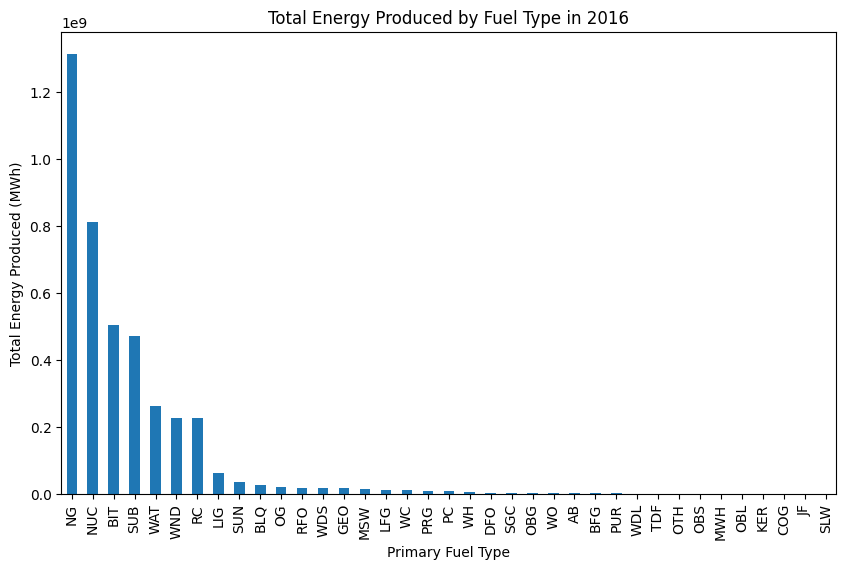

In [25]:
# 4.6. Plot a bar plot showing the amount of energy produced by each fuel type across all plants.

fuel_energy = data.groupby('PLPRMFL')['PLNGENAN'].sum().sort_values(ascending=False)
fuel_energy.plot(kind='bar', figsize=(10,6))
plt.xlabel('Primary Fuel Type')
plt.ylabel('Total Energy Produced (MWh)')
plt.title('Total Energy Produced by Fuel Type in 2016')
plt.show()

### 4.7 ###
From the plot above, NG (natural gas) is the fuel type producing the most energy in the United States.

### 4.8 ###

In [26]:
# 4.8. Which state has the largest number of hydroelectric plants?
hydro_plants = data[data['PLPRMFL'] == 'WAT']
state_hydro_counts = hydro_plants['PSTATABB'].value_counts()
max_hydro_state = state_hydro_counts.idxmax()
max_hydro_count = state_hydro_counts.max()
print(f"State with the largest number of hydroelectric plants: {max_hydro_state} with {max_hydro_count} plants.")

State with the largest number of hydroelectric plants: CA with 264 plants.


### 4.9 ###

In [27]:
# 4.9. Which state has generated the most energy (MWh) using coal? You may also want to explore the documentation for the isin() method for pandas. Note: in the eGrid documentation, there are multiple types of coal listed; be sure to factor in each type of coal.

coal_types = ['BIT', 'LIG', 'SUB', 'RC', 'WC']

coal_plants = data[data['PLPRMFL'].isin(coal_types)]
state_coal_energy = coal_plants.groupby('PSTATABB')['PLNGENAN'].sum()
max_coal_state = state_coal_energy.idxmax()
max_coal_energy_value = state_coal_energy.max()

print(f"State with the most energy generated using coal: {max_coal_state} with {max_coal_energy_value} MWh.")

State with the most energy generated using coal: TX with 122545095.0 MWh.


### 4.10 ###

In [28]:
"""
Which primary fuel produced the most CO2 emissions in the United States? We would like to compare natural gas, coal, oil, and renewables but the current categories are much more specific than that. As a first step, group the data as shown below, replacing the existing labels with the replacements suggested. For example, BIT and LIG should be replaced with COAL.

COAL = BIT, LIG, RC, SUB, WC
OIL = DFO, JF, KER, RFO, WO
GAS = BFG, COG, LFG, NG, OG, PG, PRG
RENEW = GEO, SUN, WAT, WDL, WDS, WND
You may want to create a function that does this replacement prior to running your code. You can check whether or not it was successful by verifying that each of the values that should be replaced has been replaced - check that before moving on with the question.

You will want to use ‘PLCO2EQA’ to answer this question as it’s the quantity of emissions each plant generates.
"""

def map_fuel_type(fuel_code):
    if fuel_code in ['BIT', 'LIG', 'RC', 'SUB', 'WC']:
        return 'COAL'
    elif fuel_code in ['DFO', 'JF', 'KER', 'RFO', 'WO']:
        return 'OIL'
    elif fuel_code in ['BFG', 'COG', 'LFG', 'NG', 'OG', 'PG', 'PRG']:
        return 'GAS'
    elif fuel_code in ['GEO', 'SUN', 'WAT', 'WDL', 'WDS', 'WND']:
        return 'RENEW'
    else:
        return 'OTHER'
data['FUEL_GROUP'] = data['PLPRMFL'].apply(map_fuel_type)
fuel_co2_emissions = data.groupby('FUEL_GROUP')['PLCO2EQA'].sum()
max_co2_fuel = fuel_co2_emissions.idxmax()
max_co2_value = fuel_co2_emissions.max()
print(f"Primary fuel that produced the most CO2 emissions: {max_co2_fuel} with {max_co2_value} tons.")


Primary fuel that produced the most CO2 emissions: COAL with 1398668540.658 tons.


In [45]:

# !jupyter nbconvert --to pdf hw1.out.ipynb --TemplateExporter.exclude_input_prompt=True
# !pip install nbconvert

!jupyter nbconvert --to html hw1.out.ipynb --TemplateExporter.exclude_input_prompt=True


[NbConvertApp] Converting notebook hw1.out.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 546765 bytes to hw1.out.html
